In [1]:
import sys
sys.path.append("/home/export/sdurgut/scratch/alps/tracking_ALPs/")
sys.path.append('/home/export/sdurgut/scratch/alps/bkg/FORESEE/alp')
sys.path.append('/home/export/sdurgut/scratch/alps/bkg/FORESEE')
src_path = "../"
sys.path.append(src_path)
import numpy as np
from analysis.module_VBF import TRT_length, read_data, raw_to_events
import numpy as np
import math
import matplotlib.pyplot as plt
from src.foresee import Foresee, Utility, Model
import pandas as pd
from scripts.plotting.param_space_plotting_utils import calculate_n2g
from scripts.analysis_helpers.file_helpers import ma_to_name
from analysis.module_VBF import TRT_length, displaced_vertex_TRT, conv_prob_novec, load_conv_prob_table
from pathlib import Path

PROJECT_ROOT = Path('/home/export/sdurgut/scratch/alps/tracking_ALPs')
sys.path.insert(0, str(PROJECT_ROOT / 'analysis'))
sys.path.insert(0, str(PROJECT_ROOT))


In [2]:
load_conv_prob_table('/home/export/sdurgut/scratch/alps/tracking_ALPs/data/material_budget/phase1_material_budget.txt')

array([[0.03135096, 0.05337333, 0.06746143, 0.09182115, 0.10155143,
        0.15230455, 0.18712516, 0.19475251, 0.21610152, 0.23115345,
        0.25782331, 0.2684126 , 0.29048438, 0.3110454 , 0.34221752,
        0.3532161 , 0.38218272, 0.3953736 , 0.4379932 , 0.45002378,
        0.46836033, 0.49885908, 0.51707976, 0.52933184, 0.55309781,
        0.60143436, 0.60252559, 0.6378089 , 0.65601557, 0.66817602,
        0.69216565, 0.71686905, 0.74342454, 0.7592642 , 0.77379728,
        0.7954803 , 0.80994467, 0.82625673, 0.84614561, 0.86318579,
        0.88847821, 0.91824272, 0.94884168, 0.94944164, 0.9671994 ,
        0.99254976, 1.00329303, 1.03506373, 1.04535788, 1.07192679,
        1.08743612, 1.12166286, 1.12311493, 1.15658465, 1.16478418,
        1.20862359, 1.20863697, 1.2194186 , 1.25748281, 1.2739606 ,
        1.31034834, 1.36481113, 1.37392086, 1.38979139, 1.40443533,
        1.41522332, 1.44405613, 1.48410303, 1.48622682, 1.48897267,
        1.52261456, 1.52739669, 1.56440237, 1.56

In [3]:
  hard = pd.read_csv(
      "/home/export/sdurgut/scratch/alps/bkg/FORESEE/alp/kl_vbf_sample.csv",
      usecols=["kl_pt", "kl_eta", "kl_phi",
               "g1_eta", "g1_phi", "g2_eta", "g2_phi"],
  )

In [4]:
hard.head()

,kl_pt,kl_eta,kl_phi,g1_eta,g1_phi,g2_eta,g2_phi
0,1.221928,3.398687,2.405996,2.744286,2.655796,3.553651,2.311284
1,0.784339,-0.084590,-0.397019,0.503525,-0.437465,-0.690306,-0.353112
2,0.406246,-3.687002,1.644737,-3.762817,1.784212,-1.344970,0.716872
3,2.045088,3.769091,2.952689,3.695930,2.497951,3.752773,3.075633
4,0.185914,4.456389,-0.049879,3.317376,-0.298267,3.585880,2.581221


In [5]:
np.random.seed(1234)
M_KL, CTAU_KL = 0.497611, 15.34          # GeV, m
TRACK_RES     = 4e-5                      # m
BR_KL_GG      = 5.47e-4
L_FB          = 312
SIGMA_HARD_PB = 3.6413e-3 * 1e9           # HardQCD (pThat>80) xsec, mb -> pb
N_HARD        = 20_000_000                # hard events generated (400 x 50k)
w_kaon = (SIGMA_HARD_PB / N_HARD) * (L_FB * 1e3) * BR_KL_GG   # physical K_L->gg events per r
print(f"{len(hard):,} kaons, w = {w_kaon:.3e} events/row, total = {len(hard)*w_kaon:.3e}")
b_kl = []
n_intracker = n_2conv = 0
for r in hard.itertuples():
    L = TRT_length(r.kl_eta)
    if L <= 0:
        continue
    ell = (r.kl_pt * np.cosh(r.kl_eta) / M_KL) * CTAU_KL     # lab decay length [m]
    l_a = -ell * np.log(np.random.uniform())                 # sampled decay position
    if l_a >= L:
        continue                                             # decays beyond tracker
    n_intracker += 1
    l_tracks = []
    for eta_g in (r.g1_eta, r.g2_eta):
        P = conv_prob_novec(abs(eta_g)) * (1.0 - l_a / L)    # conversion prob from l_a
        if np.random.uniform() > P:
            break
        x = np.random.uniform(l_a, L)                        # conversion point (homogeneous)
        l_tracks.append(L - x)                               # remaining track length
    if len(l_tracks) < 2:
        continue
    n_2conv += 1
    b = displaced_vertex_TRT(r.kl_eta, r.g1_phi, r.g2_phi, r.kl_phi,
                             l_tracks[0], l_tracks[1], l_a, TRACK_RES)
    b_kl.append(b)

b_kl = np.array(b_kl)
print(f"in tracker: {n_intracker:,}   double-conv: {n_2conv:,}   b~ entries: {len(b_kl):,}")
print(f"physical yield represented: {len(b_kl)*w_kaon:.3e} events @ {L_FB}/fb")

6,211,275 kaons, w = 3.107e+01 events/row, total = 1.930e+08
in tracker: 145,472   double-conv: 15,397   b~ entries: 15,397
physical yield represented: 4.784e+05 events @ 312/fb


In [11]:
np.save('b_kl_hard.npy', b_kl)          # cache â the loop is the slow part

In [6]:
w = np.full(len(b_kl), w_kaon)

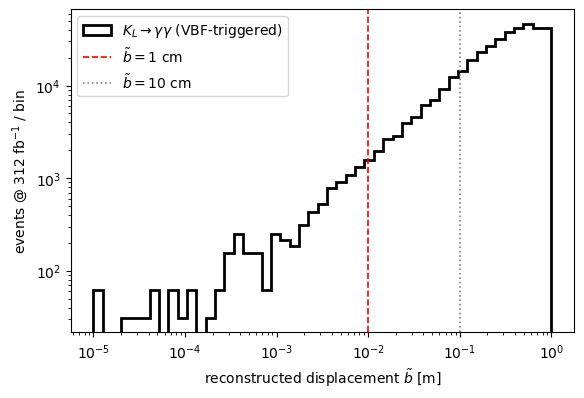

b~ = 0 (not taggable as displaced): 0.1% of entries
N(b~ > 0.01 m) = 4.697e+05
N(b~ > 0.1 m) = 4.154e+05


In [23]:
fig, ax = plt.subplots(figsize=(6.5, 4.2))

pos = b_kl > 0                                   # b~=0 -> vertex not taggable as displaced
bins = np.logspace(-5, 0, 50)                    # 10 um .. 1 m
ax.hist(b_kl[pos], bins=bins, weights=w[pos], histtype="step", lw=2, color="black",
        label=r"$K_L \to \gamma\gamma$ (VBF-triggered)")

ax.axvline(1e-2, color="red",  ls="--", lw=1.2, label=r"$\tilde{b} = 1$ cm")
ax.axvline(1e-1, color="gray", ls=":",  lw=1.2, label=r"$\tilde{b} = 10$ cm")

ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel(r"reconstructed displacement $\tilde{b}$ [m]")
ax.set_ylabel(r"events @ 312 fb$^{-1}$ / bin")
ax.legend(fontsize=10)
plt.show()

frac0 = 1 - pos.mean()
print(f"b~ = 0 (not taggable as displaced): {frac0:.1%} of entries")
for cut in (1e-2, 1e-1):
    print(f"N(b~ > {cut:g} m) = {(w[(b_kl > cut)]).sum():.3e}")

In [7]:
def load_events(gagg_list, ma, era='run3'):

    ma_name = ma_to_name(ma)
    raw_events = read_data(
        ma_name,
        num=100000,                              # max events to load
        data_dir=str(PROJECT_ROOT / 'data/cmsrun3-csvs'),
    )
    events = raw_to_events(raw_events, gaggs=gagg_list, ma=ma, era=era)
    print(f'Loaded {len(events)} events')
    return events

In [8]:
alp_0p01 = load_events([1e-4], 0.01)
alp_0p10 = load_events([1e-4], 0.10)
alp_1p00 = load_events([1e-4], 1.00)
alp_10p00 = load_events([1e-4], 10.00)

Loaded 40000 events
Loaded 40000 events
Loaded 40000 events
Loaded 40000 events


In [9]:
MA, GAGG_BENCH = 0.1, [1e-4, 1e-3, 1e-2]     # GeV ; GeV^-1
N_GEN, L_FB, XSEC_1E2, TRACK_RES = 40000, 312, 180.0, 4e-5
M_KL, CTAU_KL, BR = 0.497611, 15.34, 5.47e-4
raw = read_data(ma_to_name(MA), num=N_GEN, data_dir=str(PROJECT_ROOT/'data/cmsrun3-csvs'))
events = raw_to_events(raw, gaggs=GAGG_BENCH, ma=MA, era='run3')
print(f'loaded {len(events)} events at m_a = {MA} GeV')

loaded 40000 events at m_a = 0.1 GeV


In [10]:
def b_alp_for(i_g):
    out = []
    for ev in events:
        if not (ev['g1']['conv'][i_g] and ev['g2']['conv'][i_g]):
            continue
        out.append(displaced_vertex_TRT(
            ev['a']['eta'], ev['g1']['phi'], ev['g2']['phi'], ev['a']['phi'],
            ev['g1']['l_track'][i_g], ev['g2']['l_track'][i_g],
            ev['a']['l'][i_g], TRACK_RES))
    return np.array(out)

b_alp = {g: b_alp_for(i) for i, g in enumerate(GAGG_BENCH)}
w_alp = {g: (L_FB*1e3) * XSEC_1E2*(g/1e-2)**2 / N_GEN for g in GAGG_BENCH}

In [26]:
soft = pd.read_csv('/home/export/sdurgut/scratch/alps/bkg/FORESEE/alp/kl_sample.csv',
                   usecols=['pt', 'eta', 'phi', 'E'])

In [11]:
N_SOFT, SIGMA_INEL_PB = 2_000_000, 78.585e9
w_kaon_soft = (SIGMA_INEL_PB/N_SOFT) * (L_FB*1e3) * BR

In [28]:
pt, eta, phi, E = (soft[c].values for c in ('pt', 'eta', 'phi', 'E'))
p    = pt * np.cosh(eta)
ell  = (p / M_KL) * CTAU_KL
L    = np.vectorize(TRT_length)(eta)
l_a  = -ell * np.log(np.random.uniform(size=len(p)))
ok   = (L > 0) & (l_a < L)
print(f'in tracker: {ok.sum():,} / {len(p):,}')

in tracker: 208,144 / 8,119,246


In [12]:
def decay_photons(pt_k, eta_k, phi_k, E_k):
    """isotropic K_L->gg, boosted along the true kaon direction; returns (eta,phi) x2."""
    pk = pt_k*np.cosh(eta_k)
    pvec = np.array([pt_k*np.cos(phi_k), pt_k*np.sin(phi_k), pt_k*np.sinh(eta_k)])
    beta = pvec/E_k; b2 = beta@beta; gam = E_k/M_KL; Es = M_KL/2
    cth = np.random.uniform(-1, 1); sth = np.sqrt(1-cth*cth); ph = np.random.uniform(0, 2*np.pi)
    ps = Es*np.array([sth*np.cos(ph), sth*np.sin(ph), cth])
    out = []
    for s in (ps, -ps):
        fac = ((gam-1)*(beta@s)/b2 + gam*Es) if b2 > 0 else gam*Es
        pl = s + fac*beta
        ptl = np.hypot(pl[0], pl[1])
        out += [(np.arcsinh(pl[2]/ptl), np.arctan2(pl[1], pl[0]))]
    return out

In [30]:
b_kl_soft = []
for i in np.where(ok)[0]:
    (e1, f1), (e2, f2) = decay_photons(pt[i], eta[i], phi[i], E[i])
    ls = []
    for eg in (e1, e2):
        P = conv_prob_novec(abs(eg)) * (1.0 - l_a[i]/L[i])
        if np.random.uniform() > P: break
        x = np.random.uniform(l_a[i], L[i])
        ls.append(L[i] - x)
    if len(ls) < 2: continue
    b_kl_soft.append(displaced_vertex_TRT(eta[i], f1, f2, phi[i], ls[0], ls[1], l_a[i], TRACK_RES))
b_kl_soft = np.array(b_kl_soft)

In [33]:
print(f'K_L b~ entries: {len(b_kl_soft):,}  (N_phys = {len(b_kl_soft)*w_kaon_soft:.3e})')
np.save('b_kl_soft.npy', b_kl_soft)

K_L b~ entries: 21,987  (N_phys = 1.474e+11)


In [13]:
b_kl_soft = np.load('b_kl_soft.npy')

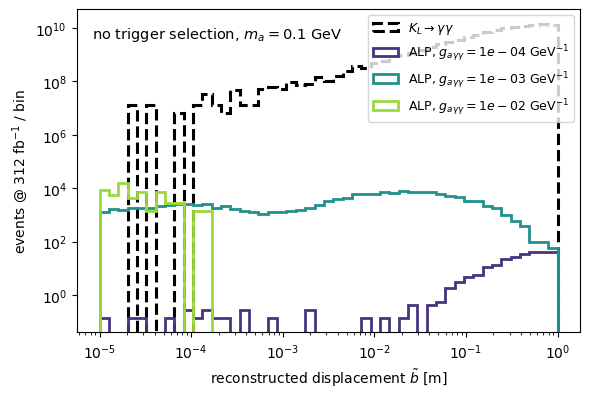

In [ ]:
fig, ax = plt.subplots(figsize=(6.5, 4.2))
bins = np.logspace(-5, 0, 50)
m = b_kl_soft > 0
ax.hist(b_kl_soft[m], bins=bins, weights=np.full(m.sum(), w_kaon_soft),
        histtype='step', lw=2.2, color='black', ls='--', label=r'$K_L \to \gamma\gamma$')
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(GAGG_BENCH)))
for g, c in zip(GAGG_BENCH, colors):
    b = b_alp[g]; m = b > 0
    if m.sum() == 0: continue
    ax.hist(b[m], bins=bins, weights=np.full(m.sum(), w_alp[g]),
            histtype='step', lw=2.0, color=c,
            label=rf'ALP, $g_{{a\gamma\gamma}}={g:.0e}$ GeV$^{{-1}}$')
ax.axvline(1e-2, color="red",  ls="--", lw=1.2, label=r"$\tilde{b} = 1$ cm")
ax.axvline(1e-1, color="gray", ls=":",  lw=1.2, label=r"$\tilde{b} = 10$ cm")            
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'reconstructed displacement $\tilde{b}$ [m]')
ax.set_ylabel(rf'events @ {L_FB} fb$^{{-1}}$ / bin')
ax.text(0.03, 0.95, rf'no trigger selection, $m_a={MA}$ GeV', transform=ax.transAxes,
        fontsize=10.5, va='top')
ax.legend(fontsize=9, loc='upper right')
fig.savefig('displacement_alp_vs_kl_inclusive.pdf')
plt.show()

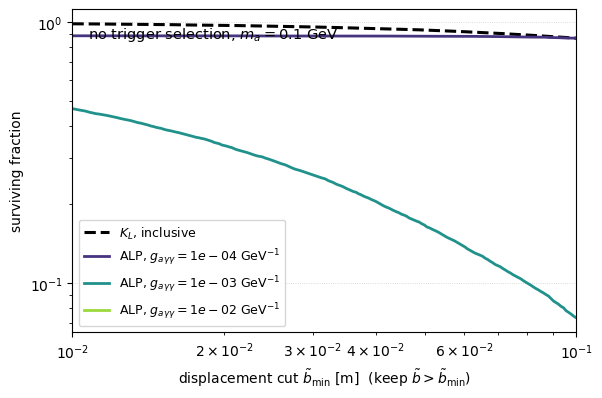

b~ > 1 cm :  K_L=9.84e-01   ALP(1e-04)=8.85e-01   ALP(1e-03)=4.65e-01   ALP(1e-02)=0.00e+00
b~ > 10 cm :  K_L=8.66e-01   ALP(1e-04)=8.67e-01   ALP(1e-03)=7.35e-02   ALP(1e-02)=0.00e+00


In [15]:

import matplotlib.pyplot as plt, numpy as np

def eff_disp(b, cuts):
    """Fraction of the FULL sample with b~ > cut (b~=0 entries count as failing)."""
    b = np.asarray(b)
    return np.array([(b > c).mean() for c in cuts])

cuts = np.logspace(-2, -1, 200)          # 1 cm -> 10 cm

fig, ax = plt.subplots(figsize=(6.5, 4.2))

ax.plot(cuts, eff_disp(b_kl_soft, cuts), lw=2.2, color="black", ls="--",
        label=r"$K_L$, inclusive")

colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(GAGG_BENCH)))
for g, c in zip(GAGG_BENCH, colors):
    if (np.asarray(b_alp[g]) > 0).sum() == 0:
        continue
    ax.plot(cuts, eff_disp(b_alp[g], cuts), lw=2.0, color=c,
            label=rf"ALP, $g_{{a\gamma\gamma}}={g:.0e}$ GeV$^{{-1}}$")

ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel(r"displacement cut $\tilde{b}_{\min}$ [m]  (keep $\tilde{b} > \tilde{b}_{\min}$)")
ax.set_ylabel("surviving fraction")
ax.set_xlim(1e-2, 1e-1)
ax.text(0.03, 0.95, rf"no trigger selection, $m_a={MA}$ GeV", transform=ax.transAxes,
        fontsize=10.5, va="top")
ax.grid(True, which="major", ls=":", lw=0.6, alpha=0.6)
ax.legend(fontsize=9, loc="lower left")
fig.savefig("displacement_efficiency_inclusive.pdf")
plt.show()

# numbers at the two benchmark cuts
for cut in (1e-2, 1e-1):
    line = f"b~ > {cut*100:g} cm :  K_L={(np.asarray(b_kl_soft)>cut).mean():.2e}"
    for g in GAGG_BENCH:
        line += f"   ALP({g:.0e})={(np.asarray(b_alp[g])>cut).mean():.2e}"
    print(line)


In [16]:
b = np.asarray(b_kl_soft)
print("total entries:", len(b))
print("b~ == 0:", (b == 0).sum(), f"({(b==0).mean():.1%})")
print("b~ > 1cm:", (b > 1e-2).mean(), "   b~ > 10cm:", (b > 1e-1).mean())
print("median of b~>0:", np.median(b[b>0]))


total entries: 21987
b~ == 0: 9 (0.0%)
b~ > 1cm: 0.983808614181107    b~ > 10cm: 0.8664210669941329
median of b~>0: 0.4558873096340569


VBF-passing: 492 / 40000
gagg=3e-04: 30 entries, N_phys = 3.791e+01
gagg=1e-03: 130 entries, N_phys = 1.825e+03
gagg=3e-03: 153 entries, N_phys = 1.933e+04


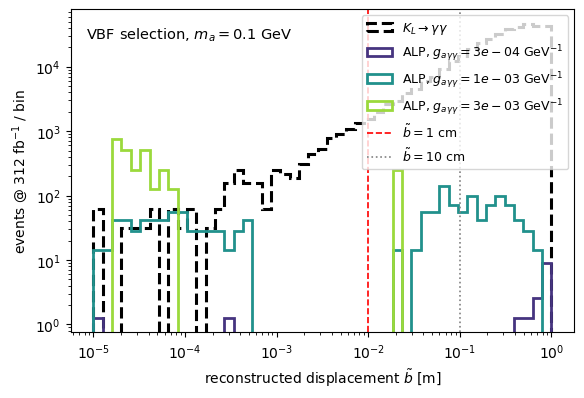

b~ > 0.01 m :  B=4.697e+05   S(3e-04)=2.654e+01   S(1e-03)=8.705e+02   S(3e-03)=2.527e+02
b~ > 0.1 m :  B=4.154e+05   S(3e-04)=2.654e+01   S(1e-03)=5.054e+02   S(3e-03)=0.000e+00


In [38]:
MA         = 0.1                        # GeV
GAGG_BENCH = [3e-4, 1e-3, 3e-3]         # GeV^-1
N_GEN, XSEC_1E2 = 40000, 180.0
from scripts.analysis_helpers.kinematics_helpers import compute_mjj
raw = read_data(ma_to_name(MA), num=N_GEN,
                data_dir='/home/export/sdurgut/scratch/alps/tracking_ALPs/data/cmsrun3-csvs')
events = raw_to_events(raw, gaggs=GAGG_BENCH, ma=MA, era='run3')

def passes_vbf(ev):
    lead, sub = max(ev['j1']['pt'], ev['j2']['pt']), min(ev['j1']['pt'], ev['j2']['pt'])
    return (lead > 105.0 and sub > 40.0 and compute_mjj(ev) > 720.0
            and abs(ev['j1']['eta'] - ev['j2']['eta']) > 3.0)

events_vbf = [ev for ev in events if passes_vbf(ev)]
print(f'VBF-passing: {len(events_vbf)} / {len(events)}')

def b_alp_for(i_g):
    out = []
    for ev in events_vbf:
        if not (ev['g1']['conv'][i_g] and ev['g2']['conv'][i_g]):
            continue
        out.append(displaced_vertex_TRT(
            ev['a']['eta'], ev['g1']['phi'], ev['g2']['phi'], ev['a']['phi'],
            ev['g1']['l_track'][i_g], ev['g2']['l_track'][i_g],
            ev['a']['l'][i_g], TRACK_RES))
    return np.array(out)

b_alp = {g: b_alp_for(i) for i, g in enumerate(GAGG_BENCH)}
w_alp = {g: (L_FB*1e3) * XSEC_1E2*(g/1e-2)**2 / N_GEN for g in GAGG_BENCH}
for g in GAGG_BENCH:
    print(f'gagg={g:.0e}: {len(b_alp[g])} entries, N_phys = {len(b_alp[g])*w_alp[g]:.3e}')

# ================= combined plot: your K_L block + signal curves =================
fig, ax = plt.subplots(figsize=(6.5, 4.2))
bins = np.logspace(-5, 0, 50)

pos = b_kl > 0
ax.hist(b_kl[pos], bins=bins, weights=np.full(pos.sum(), w_kaon),
        histtype="step", lw=2.2, color="black", ls="--",
        label=r"$K_L \to \gamma\gamma$")

colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(GAGG_BENCH)))
for g, c in zip(GAGG_BENCH, colors):
    b = b_alp[g]; m = b > 0
    if m.sum() == 0: continue
    ax.hist(b[m], bins=bins, weights=np.full(m.sum(), w_alp[g]),
            histtype="step", lw=2.0, color=c,
            label=rf"ALP, $g_{{a\gamma\gamma}}={g:.0e}$ GeV$^{{-1}}$")

ax.axvline(1e-2, color="red",  ls="--", lw=1.2, label=r"$\tilde{b} = 1$ cm")
ax.axvline(1e-1, color="gray", ls=":",  lw=1.2, label=r"$\tilde{b} = 10$ cm")

ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel(r"reconstructed displacement $\tilde{b}$ [m]")
ax.set_ylabel(r"events @ 312 fb$^{-1}$ / bin")
ax.text(0.03, 0.95, rf"VBF selection, $m_a={MA}$ GeV",
        transform=ax.transAxes, fontsize=10.5, va="top")
ax.legend(fontsize=9, loc="upper right")
fig.savefig("displacement_alp_vs_kl_vbf.pdf")
plt.show()

# survivors past the benchmark displacement cuts, both sides
for cut in (1e-2, 1e-1):
    line = f"b~ > {cut:g} m :  B={(w_kaon*(b_kl > cut).sum()):.3e}"
    for g in GAGG_BENCH:
        line += f"   S({g:.0e})={(w_alp[g]*(b_alp[g] > cut).sum()):.3e}"
    print(line)

In [37]:
for g in GAGG_BENCH:
    b = b_alp[g]
    print(f"gagg={g:.0e}: entries={len(b)}, b>0: {(b>0).sum()}, "
          f"b>1e-5 m: {(b>1e-5).sum()}, median(b>0)={np.median(b[b>0]) if (b>0).any() else float('nan'):.2e}")

gagg=1e-04: entries=0, b>0: 0, b>1e-5 m: 0, median(b>0)=nan
gagg=1e-03: entries=133, b>0: 118, b>1e-5 m: 114, median(b>0)=8.60e-02
gagg=1e-02: entries=162, b>0: 0, b>1e-5 m: 0, median(b>0)=nan


In [17]:
for g in GAGG_BENCH:
    b = np.asarray(b_alp[g])
    print(f"gagg={g:.0e}: entries>0 = {(b>0).sum()}, above 1cm = {(b>1e-2).sum()}")

gagg=1e-04: entries>0 = 2493, above 1cm = 2476
gagg=1e-03: entries>0 = 10724, above 1cm = 5418
gagg=1e-02: entries>0 = 104, above 1cm = 0
